# **🏠 Predict House Prices**

---

# Regression Modelling

## Objectives

- Fit and evaluate regression models to predict house `SalePrice`.
- Identify a model that provides suitable predictive performance on unseen data.

## Inputs

- Cleaned house prices dataset.
- Feature engineering decisions identified in the previous notebook.

## Outputs

- Train set (features and target).
- Test set (features and target).
- Data cleaning and feature engineering pipeline.
- Modelling pipeline.
- Model performance evaluation.
- Feature importance plot.

---

## ⚙️ 2. Set Up the Notebook

### Change working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/workspaces/milestone-project5-heritage-housing-issues/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chdir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/workspaces/milestone-project5-heritage-housing-issues'

---

## 📥 3. Load Data

Load the cleaned house prices dataset produced during the data cleaning stage.

In [4]:
import numpy as np
import pandas as pd

df = pd.read_csv("outputs/datasets/cleaned/house_prices_cleaned.csv")

print(df.shape)
df.head(3)

(1460, 22)


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,GarageArea,GarageFinish,GarageYrBlt,...,LotArea,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,548,RFn,2003.0,...,8450,65.0,196.0,61,5,7,856,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,460,RFn,1976.0,...,9600,80.0,0.0,0,8,6,1262,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,608,RFn,2001.0,...,11250,68.0,162.0,42,5,7,920,2001,2002,223500


---

## 🔧 4. ML Pipeline

### Feature Engineering and Modelling Pipeline

A pipeline is created to apply the feature engineering steps identified in the
previous notebook, scale and select features, and fit a regression model to
predict `SalePrice`.

In [5]:
from sklearn.pipeline import Pipeline

# Feature Engineering
from feature_engine.encoding import OrdinalEncoder, OneHotEncoder
from feature_engine import transformation as vt

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Feature Selection
from sklearn.feature_selection import SelectFromModel

# ML Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)
from xgboost import XGBRegressor


def PipelineOptimization(model):
    """
    Creates a regression pipeline using the feature engineering decisions
    identified in the Feature Engineering notebook.
    """
    pipeline_base = Pipeline([

        # CATEGORICAL ENCODING
        ("OrdinalCategoricalEncoder", OrdinalEncoder(
            encoding_method='arbitrary',
            variables=[
                'BsmtExposure',
                'GarageFinish',
                'KitchenQual'
            ]
        )),

        ("OneHotCategoricalEncoder", OneHotEncoder(
            variables=['BsmtFinType1'],
            drop_last=False
        )),

        # NUMERICAL TRANSFORMATIONS
        ("LogTransformer", vt.LogTransformer(
            variables=[
                '1stFlrSF',
                'GrLivArea',
                'LotArea',
                'LotFrontage'
            ]
        )),

        ("PowerTransformer", vt.PowerTransformer(
            variables=[
                'BsmtUnfSF',
                'TotalBsmtSF'
            ]
        )),

        # FEATURE SCALING
        ("feat_scaling", StandardScaler()),

        # FEATURE SELECTION
        ("feat_selection", SelectFromModel(model)),

        # MODEL
        ("model", model),

    ])

    return pipeline_base

### Hyperparameter Optimisation

The `HyperparameterOptimizationSearch` class is used to test multiple regression
algorithms and their hyperparameters.

The `fit` method passes each model to `PipelineOptimization()` and uses
`GridSearchCV` with cross-validation to test the specified hyperparameters.

The results are stored and `score_summary` returns a DataFrame summarising
model performance for comparison.

In [6]:
from sklearn.model_selection import GridSearchCV


class HyperparameterOptimizationSearch:

    def __init__(self, models, params):
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, X, y, cv, n_jobs, verbose=1, scoring=None):
        for key in self.keys:
            print(f"\nRunning GridSearchCV for {key} \n")

            model = PipelineOptimization(self.models[key])
            params = self.params[key]

            gs = GridSearchCV(
                model,
                params,
                cv=cv,
                n_jobs=n_jobs,
                verbose=verbose,
                scoring=scoring
            )

            gs.fit(X, y)
            self.grid_searches[key] = gs

    def score_summary(self, sort_by='mean_score'):

        def row(key, scores, params):
            d = {
                'estimator': key,
                'min_score': min(scores),
                'max_score': max(scores),
                'mean_score': np.mean(scores),
                'std_score': np.std(scores),
            }
            return pd.Series({**params, **d})

        rows = []

        for k in self.grid_searches:
            params = self.grid_searches[k].cv_results_['params']
            scores = []

            for i in range(self.grid_searches[k].cv):
                key = "split{}_test_score".format(i)
                r = self.grid_searches[k].cv_results_[key]
                scores.append(r.reshape(len(params), 1))

            all_scores = np.hstack(scores)

            for p, s in zip(params, all_scores):
                rows.append(row(k, s, p))

        df = pd.concat(rows, axis=1).T.sort_values(
            [sort_by], ascending=False
        )

        columns = [
            'estimator',
            'min_score',
            'mean_score',
            'max_score',
            'std_score'
        ]

        columns = columns + [
            c for c in df.columns if c not in columns
        ]

        return df[columns], self.grid_searches

---

## ✂️ 5. Train and Test Split

The dataset is split into training and test sets. The training set will be used
to train and optimise the regression models, while the test set will be kept
separate to evaluate performance on unseen data.


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(['SalePrice'], axis=1),
    df['SalePrice'],
    test_size=0.2,
    random_state=0,
)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1168, 21) (1168,) (292, 21) (292,)


The dataset has been split into:

- **Training set:** 1,168 observations with 21 predictor features.
- **Test set:** 292 observations with 21 predictor features.

### Train Set Target Distribution

The distribution of the training target `SalePrice` is inspected before modelling.

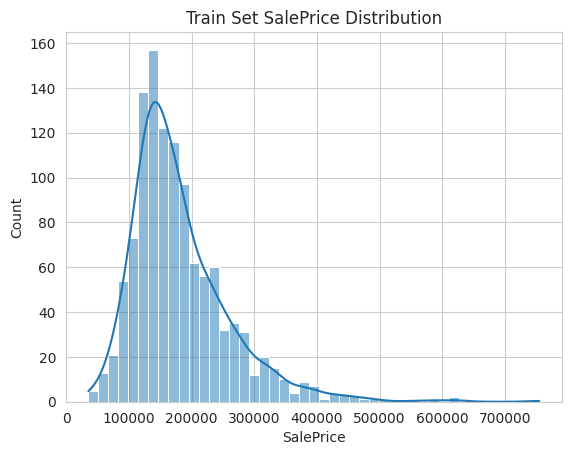

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

sns.histplot(y_train, kde=True)
plt.title("Train Set SalePrice Distribution")
plt.xlabel("SalePrice")
plt.show()

### Target Distribution Interpretation

* The training target is positively skewed. Most houses are concentrated roughly around the 100,000–250,000 range, while a smaller number of expensive houses create the long tail extending beyond 500,000.

* Before running the model no transformation will currently be performed.

In [9]:
models_quick_search = {
    "LinearRegression": LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=0),
    "RandomForestRegressor": RandomForestRegressor(random_state=0),
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=0),
    "AdaBoostRegressor": AdaBoostRegressor(random_state=0),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=0),
    "XGBRegressor": XGBRegressor(random_state=0),
}

params_quick_search = {
    "LinearRegression": {},
    "DecisionTreeRegressor": {},
    "RandomForestRegressor": {},
    "ExtraTreesRegressor": {},
    "AdaBoostRegressor": {},
    "GradientBoostingRegressor": {},
    "XGBRegressor": {},
}

### Model Performance Requirement

The project requirement is to achieve an **R² score of at least 0.75 on both
the training and test sets**.

R² will therefore be used as the primary scoring metric when comparing the
regression models.

In [10]:
search = HyperparameterOptimizationSearch(
    models=models_quick_search,
    params=params_quick_search
)

search.fit(
    X_train,
    y_train,
    scoring='r2',
    n_jobs=-1,
    cv=5
)


Running GridSearchCV for LinearRegression 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is 


Running GridSearchCV for DecisionTreeRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is 


Running GridSearchCV for RandomForestRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


...

/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is 


Running GridSearchCV for GradientBoostingRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is 


Running GridSearchCV for XGBRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is 

### Quick Search Results

The cross-validation results are summarised and ranked by mean R² score to
compare the performance of the regression algorithms using their standard
hyperparameters.

In [11]:
grid_search_summary, grid_search_pipelines = search.score_summary(
    sort_by='mean_score'
)

grid_search_summary

,estimator,min_score,mean_score,max_score,std_score
3,ExtraTreesRegressor,0.685996,0.815837,0.873806,0.066435
2,RandomForestRegressor,0.695521,0.804006,0.852613,0.060153
5,GradientBoostingRegressor,0.61232,0.775373,0.851737,0.090872
4,AdaBoostRegressor,0.677006,0.765308,0.809411,0.047067
0,LinearRegression,0.162111,0.707553,0.866118,0.273438
6,XGBRegressor,0.516448,0.653315,0.764916,0.090845
1,DecisionTreeRegressor,0.527375,0.623288,0.702554,0.076949


### Extensive Hyperparameter Search

`ExtraTreesRegressor` and `RandomForestRegressor` achieved the strongest
performance during the quick search and are therefore selected for further
optimisation.

A range of hyperparameter configurations will be evaluated using
cross-validation to investigate whether their predictive performance can
be improved.

In [12]:
models_search = {
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=0),
    "RandomForestRegressor": RandomForestRegressor(random_state=0),
}

params_search = {
    "ExtraTreesRegressor": {
        "model__n_estimators": [100, 50, 150],
        "model__max_depth": [None, 3, 15],
        "model__min_samples_split": [2, 50],
        "model__min_samples_leaf": [1, 50],
    },

    "RandomForestRegressor": {
        "model__n_estimators": [100, 50, 140],
        "model__max_depth": [None, 4, 15],
        "model__min_samples_split": [2, 50],
        "model__min_samples_leaf": [1, 50],
        "model__max_leaf_nodes": [None, 50],
    },
}

In [13]:
search = HyperparameterOptimizationSearch(
    models=models_search,
    params=params_search
)

search.fit(
    X_train,
    y_train,
    scoring='r2',
    n_jobs=-1,
    cv=5
)


Running GridSearchCV for ExtraTreesRegressor 

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is 


Running GridSearchCV for RandomForestRegressor 

Fitting 5 folds for each of 72 candidates, totalling 360 fits


/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is 

In [14]:
grid_search_summary, grid_search_pipelines = search.score_summary(
    sort_by='mean_score'
)

grid_search_summary

,estimator,min_score,mean_score,max_score,std_score,model__max_depth,model__min_samples_leaf,model__min_samples_split,model__n_estimators,model__max_leaf_nodes
27,ExtraTreesRegressor,0.769152,0.819095,0.854558,0.038712,15,1,50,100,NaN
3,ExtraTreesRegressor,0.769135,0.819092,0.854558,0.038716,None,1,50,100,NaN
29,ExtraTreesRegressor,0.769059,0.818509,0.855236,0.0387,15,1,50,150,NaN
5,ExtraTreesRegressor,0.769047,0.818486,0.855236,0.03869,None,1,50,150,NaN
26,ExtraTreesRegressor,0.696702,0.817759,0.87299,0.062868,15,1,2,150,NaN
...,...,...,...,...,...,...,...,...,...,...
58,RandomForestRegressor,0.630653,0.702457,0.755301,0.057712,None,50,50,50,50
70,RandomForestRegressor,0.625803,0.699612,0.753159,0.058215,4,50,50,50,None
67,RandomForestRegressor,0.625803,0.699612,0.753159,0.058215,4,50,2,50,None
82,RandomForestRegressor,0.625803,0.699609,0.753159,0.058218,4,50,50,50,50


Get best model name programmatically

In [15]:
best_model = grid_search_summary.iloc[0, 0]
best_model

'ExtraTreesRegressor'

Parameters for best model

In [16]:
best_parameters = grid_search_pipelines[best_model].best_params_
best_parameters

{'model__max_depth': 15,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 50,
 'model__n_estimators': 100}

In [17]:
pipeline_reg = grid_search_pipelines[best_model].best_estimator_
pipeline_reg

Pipeline(steps=[('OrdinalCategoricalEncoder',
                 OrdinalEncoder(encoding_method='arbitrary',
                                variables=['BsmtExposure', 'GarageFinish',
                                           'KitchenQual'])),
                ('OneHotCategoricalEncoder',
                 OneHotEncoder(variables=['BsmtFinType1'])),
                ('LogTransformer',
                 LogTransformer(variables=['1stFlrSF', 'GrLivArea', 'LotArea',
                                           'LotFrontage'])),
                ('PowerTransformer',
                 PowerTransformer(variables=['BsmtUnfSF', 'TotalBsmtSF'])),
                ('feat_scaling', StandardScaler()),
                ('feat_selection',
                 SelectFromModel(estimator=ExtraTreesRegressor(random_state=0))),
                ('model',
                 ExtraTreesRegressor(max_depth=15, min_samples_split=50,
                                     random_state=0))])